Wir laden zunächst wieder ein Bild aus skimage.data. Diesmal ist es jedoch ein Farbbild.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from skimage.data import astronaut
img = astronaut()

Lasst euch das Bild mit `matplotlib.pyplot` anzeigen. Was ändert sich am Aufruf im Vergleich zu Graustufenbildern?

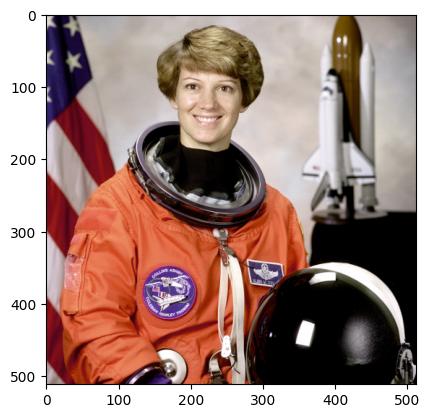

In [2]:
plt.imshow(img)

Invertiert nun das Bild. Welche Farben wird die Flagge der USA im Hintergund nun haben?

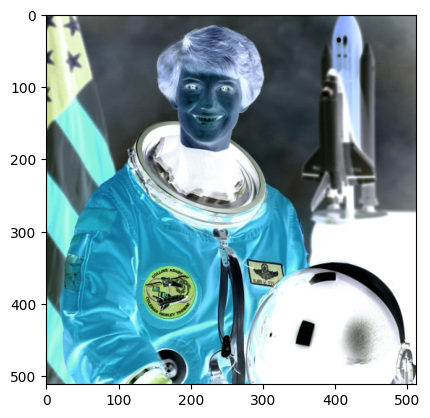

In [3]:
inverted_img = 255 - img
plt.imshow(inverted_img)

Berechnet den Mittelwert des Bildes je Farbkanal, ohne die Farbkanäle zu extrahieren.

In [7]:
mean_per_channel = np.mean(img, axis=(0, 1))
print(f"Mittelwert pro Farbkanal: R={mean_per_channel[0]:.2f}, G={mean_per_channel[1]:.2f}, B={mean_per_channel[2]:.2f}")

Mittelwert pro Farbkanal: R=141.56, G=105.76, B=96.48


Extrahiert die Farbkanäle und visualisiert diese einzeln als Graustufenbilder. Was lässt sich daraus ablesen?

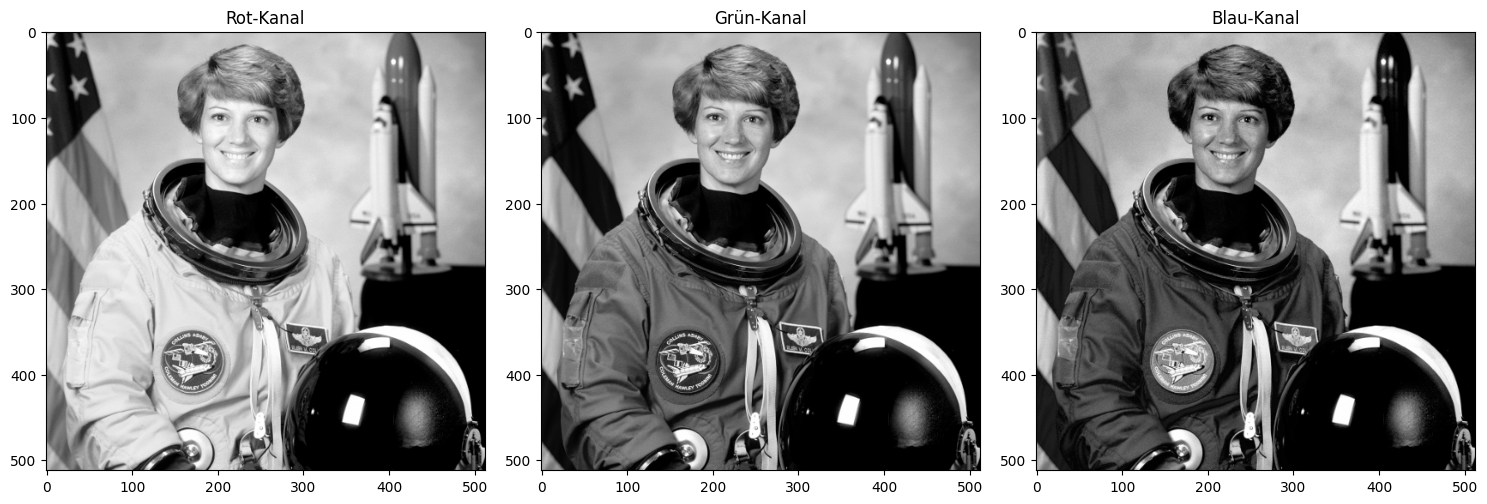

In [8]:
r_channel = img[:, :, 0]
g_channel = img[:, :, 1]
b_channel = img[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(r_channel, cmap='gray')
axes[0].set_title('Rot-Kanal')
axes[1].imshow(g_channel, cmap='gray')
axes[1].set_title('Grün-Kanal')
axes[2].imshow(b_channel, cmap='gray')
axes[2].set_title('Blau-Kanal')
plt.tight_layout()
plt.show()

Setzt die einzelnen Farbkanäle wieder zu einem Farbbild zusammen, tauscht dabei jedoch den Rot-Kanal mit den Blau-Kanal. Was wird sich nun ändern im Vergleich zum Original?

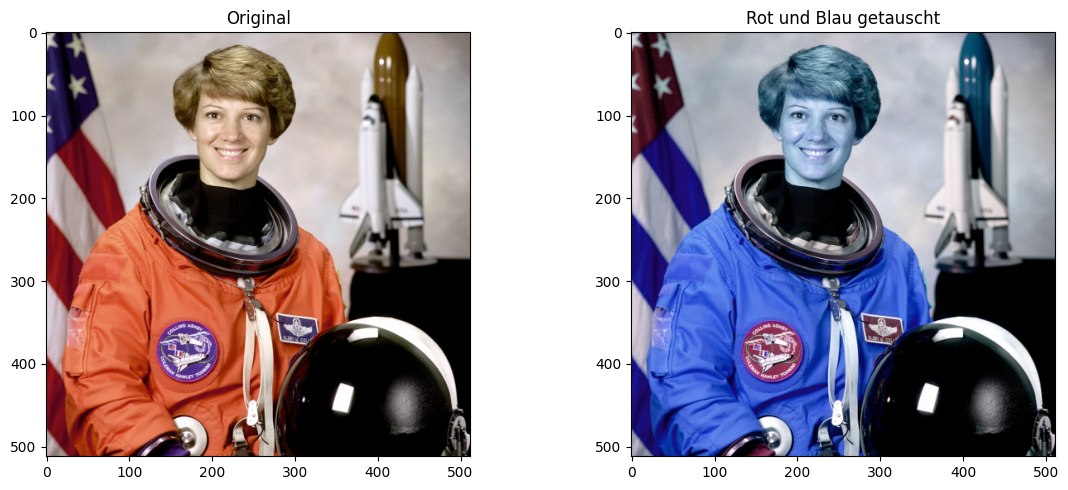

In [14]:
swapped_img = np.dstack([b_channel, g_channel, r_channel])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[1].imshow(swapped_img)
axes[1].set_title('Rot und Blau getauscht')
plt.tight_layout()
plt.show()

Wandelt nun das Bild in eine Graustufenbild um.

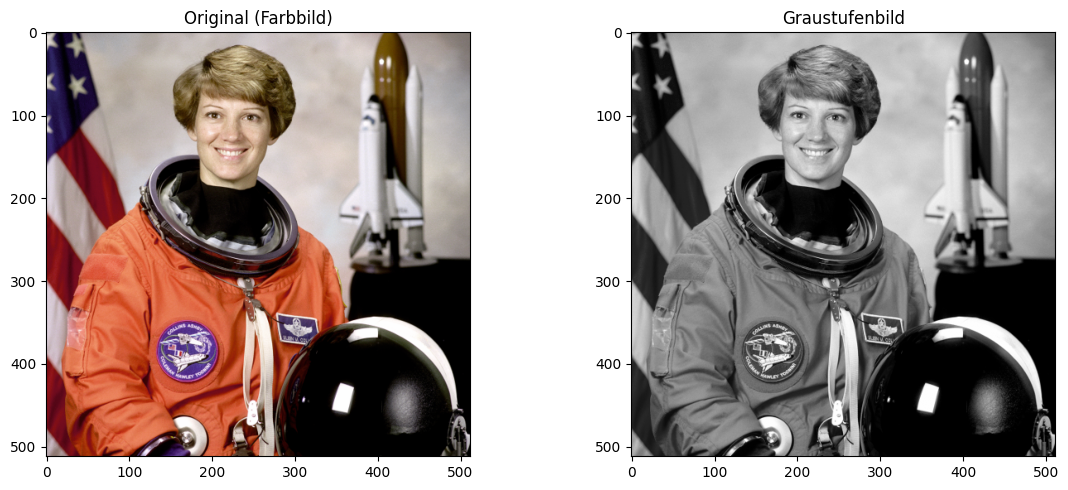

Original Bildtyp: uint8, Shape: (512, 512, 3)
Graustufen Bildtyp: float64, Shape: (512, 512)


In [11]:
from skimage.color import rgb2gray

gray_img = rgb2gray(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Original (Farbbild)')
axes[1].imshow(gray_img, cmap='gray')
axes[1].set_title('Graustufenbild')
plt.tight_layout()
plt.show()

print(f"Original Bildtyp: {img.dtype}, Shape: {img.shape}")
print(f"Graustufen Bildtyp: {gray_img.dtype}, Shape: {gray_img.shape}")

Transformiert das Bild nun in den HSV-Farbraum und dreht die Sättigung voll auf. Welche Auswirkungen hat dies auf das Bild?

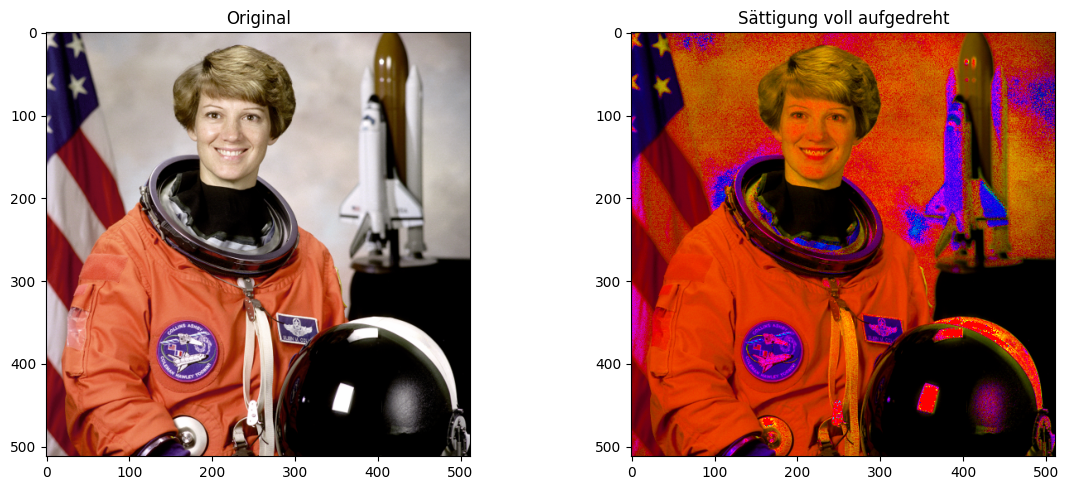

In [12]:
from skimage.color import rgb2hsv, hsv2rgb

# Konvertiere zu HSV
hsv_img = rgb2hsv(img)

# Drehe Sättigung voll auf (auf 1.0)
hsv_saturated = hsv_img.copy()
hsv_saturated[:, :, 1] = 1.0

# Konvertiere zurück zu RGB
saturated_img = hsv2rgb(hsv_saturated)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[1].imshow(saturated_img)
axes[1].set_title('Sättigung voll aufgedreht')
plt.tight_layout()
plt.show()

Rotiert nun den Farbwert (hue) im Farbkreis um bspw. 120 oder 240 Grad. Welche Auswirkungen auf das Bild hat diese Veränderung?